# Analysis

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import helper module
# import sys
# sys.path.insert(0, '..')
# from src.helpers import *

df = pd.read_csv("../data/naloxone_clean.csv") # main dataset

wards = pd.read_csv("../data/ward_demographics.csv") # supplementary dataset

## Q1. How have naloxone incidents evolved over the years?
This chart shows the total number of incidents registered and the total number of naloxone doses administered for each year from 2008-2025 (2007 and 2026 excluded because of partial data, making the chart misleading).

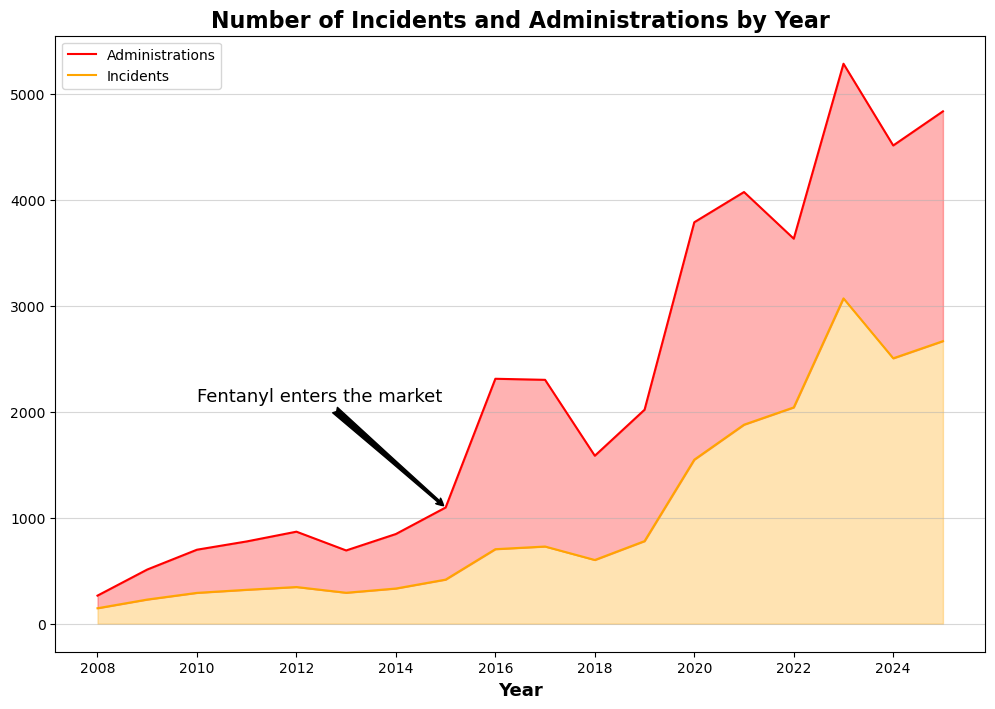

In [7]:
# preparing the data to plot
by_year = df.groupby("year")
administrations_year = by_year["naloxone_administrations"].sum().loc[2008:2025]
incidents_year = by_year["incident_number"].nunique().loc[2008:2025]

# plotting
fig, ax = plt.subplots(figsize=(12, 8))

# plot both lines
ax.plot(administrations_year.index, administrations_year, color="red", label="Administrations")
ax.plot(incidents_year.index, incidents_year, color="orange", label="Incidents")

# fill both areas
ax.fill_between(incidents_year.index, incidents_year, color="orange", alpha=0.3)
ax.fill_between(administrations_year.index, incidents_year, administrations_year, color="red", alpha=0.3)

# text + arrow annotation about fentanyl
ax.annotate("Fentanyl enters the market",
            xy=(2015, administrations_year[2015]),
            xytext=(2015 - 5, administrations_year[2015] + 1000),
            arrowprops=dict(arrowstyle="fancy", color="black"),
            fontsize=13)


ax.set_xticks([2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024])

# labeling the plot
ax.set_title("Number of Incidents and Administrations by Year", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.5)

# displaying the chart
ax.legend()
plt.show()

Incidents have grown steadily since 2008, with a sharp spike in 2015 to 2018. The year of 2015 was the arrival of fentanyl to the Winnipeg's drug market, which explains why administrations spiked much faster than incidents during that time: the same number of patients started requiring more doses to reverse overdoses. The gap between the two lines is a measure of how much more dangerous drugs became over time.

## Q2. Are there temporal patterns in when incidents occur?
This chart breaks down incidents by day of the week and by hour of the day, to see if overdoses cluster at specific times.

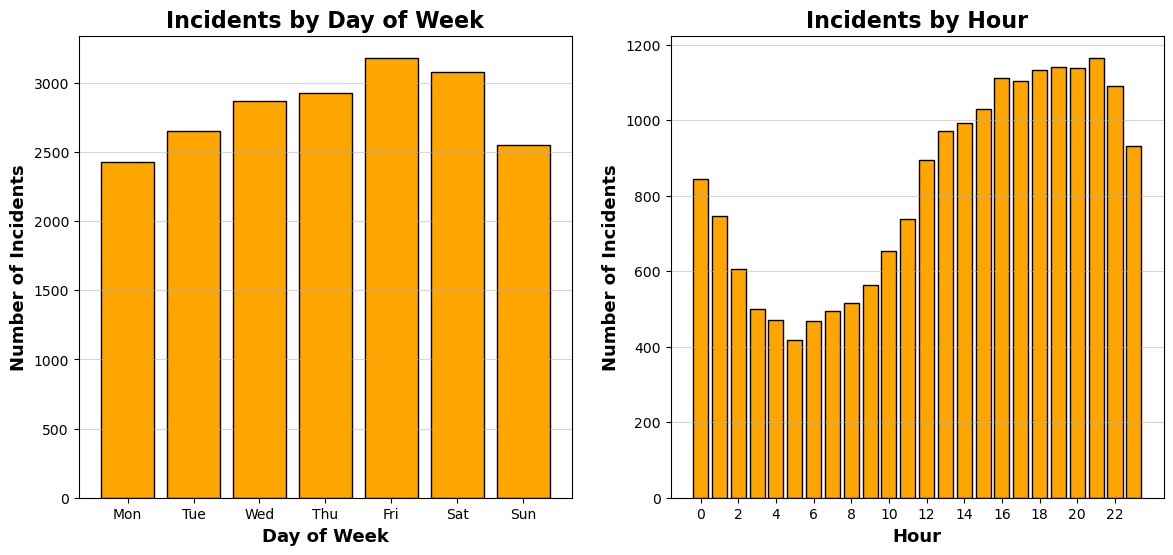

In [8]:
# preparing the data
incidents_dow = df.groupby("day_of_week")["incident_number"].nunique()
incidents_hour = df.groupby("hour")["incident_number"].nunique()

# plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# plotting left bar chart (incidents by day of week)
ax[0].bar(incidents_dow.index, incidents_dow, color="orange", edgecolor="black")
ax[0].set_xticks(np.arange(0, 7))

# labeling left bar chart
ax[0].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax[0].set_title("Incidents by Day of Week", fontsize=16, fontweight="bold")
ax[0].set_xlabel("Day of Week", fontsize=13, fontweight="bold")
ax[0].set_ylabel("Number of Incidents", fontsize=13, fontweight="bold")

# plotting right bar chart (incidents by hour)
ax[1].bar(incidents_hour.index, incidents_hour, color="orange", edgecolor="black", width=0.8)
ax[1].set_xticks(np.arange(0, 24, 2))

# labeling right bar chart
ax[1].set_title("Incidents by Hour", fontsize=16, fontweight="bold")
ax[1].set_xlabel("Hour", fontsize=13, fontweight="bold")
ax[1].set_ylabel("Number of Incidents", fontsize=13, fontweight="bold")

# setting the grid for both charts
ax[0].grid(axis="y", alpha=0.5)
ax[1].grid(axis="y", alpha=0.5)

# displaying the figure
plt.show()

Incidents are relatively consistent across all days of the week, with a slight peak on Fridays and Saturdays. The hour chart tells a clearer story: incident volume appears to follow daily activity cycles, with a low point at 5am and a gradual buildup throughout the day, peaking at 8pm before declining through the night.

## Q3. Which wards are most affected by overdose incidents?
The visualizations below explore the geographic distribution of incidents across Winnipeg's 15 wards and whether socioeconomic factors might help explain the differences between them.

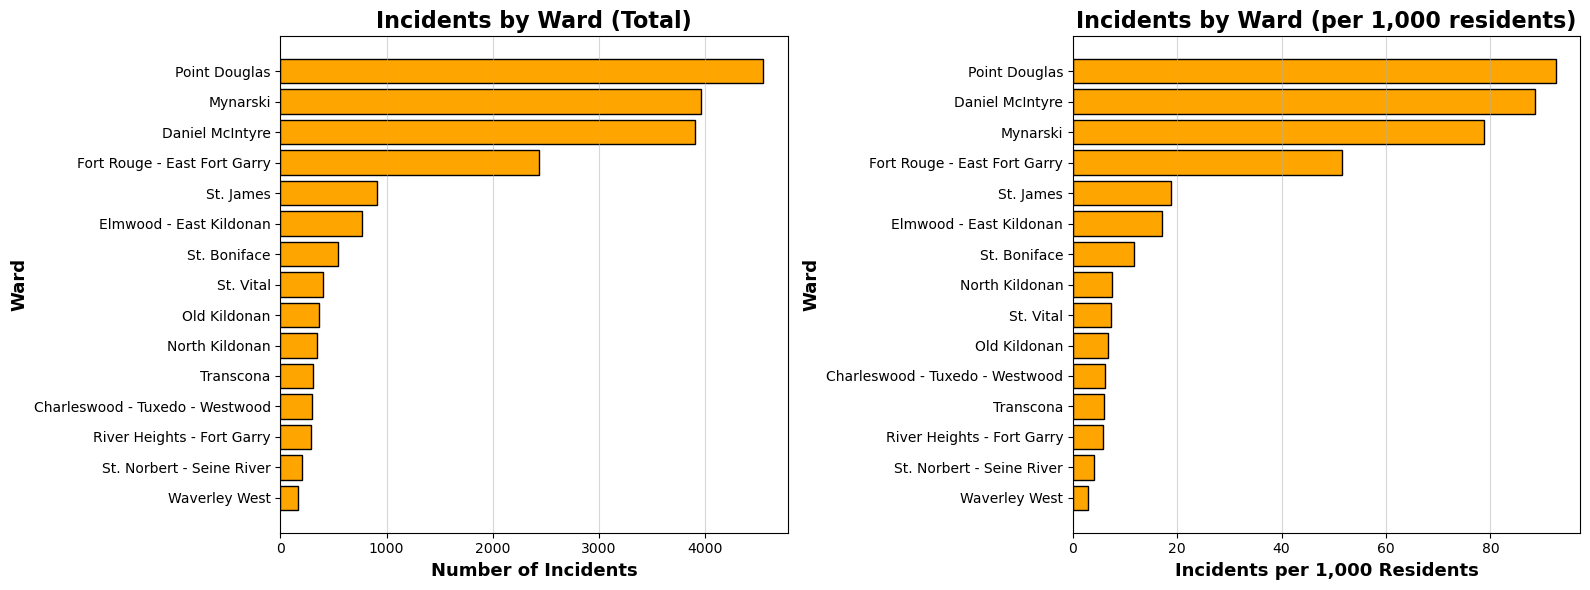

In [9]:
# preparing the data

# resetindex to turn groupby into a regular df
by_ward = df.groupby("ward")["incident_number"].nunique().reset_index()
by_ward.columns = ["ward", "incidents"] # renaming incident_number to incidents
by_ward = by_ward.merge(wards, on="ward") # merging supplementary dataset on `ward` column

# creating new column to hold incidents per 1000 residents
by_ward["incidents_per_1000"] = (by_ward["incidents"] / by_ward["population"]) * 1000

sorted_df = by_ward.sort_values("incidents")
sorted_normalized_df = by_ward.sort_values("incidents_per_1000")

# plotting
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# plotting left barh chart (not normalized - raw total incidents)
ax[0].barh(sorted_df["ward"], sorted_df["incidents"], color="orange", edgecolor="black")

# labeling left barh
ax[0].set_title("Incidents by Ward (Total)", fontsize=16, fontweight="bold")
ax[0].set_xlabel("Number of Incidents", fontsize=13, fontweight="bold")
ax[0].set_ylabel("Ward", fontsize=13, fontweight="bold")
ax[0].grid(axis="x", alpha=0.5)

# plotting right barh (normalized by incidents per 1000 residents)
ax[1].barh(sorted_normalized_df["ward"], sorted_normalized_df["incidents_per_1000"],
           color="orange", edgecolor="black")

# labeling right barh
ax[1].set_title("Incidents by Ward (per 1,000 residents)", fontsize=16, fontweight="bold")
ax[1].set_xlabel("Incidents per 1,000 Residents", fontsize=13, fontweight="bold")
ax[1].set_ylabel("Ward", fontsize=13, fontweight="bold")
ax[1].grid(axis="x", alpha=0.5)

# displaying the figure
plt.tight_layout()
plt.show()

Point Douglas, Mynarski, and Daniel McIntyre lead in both total incidents and incidents per 1,000 residents, which rules out population size as an explanation. This raises the question: what makes these wards different? The chart below looks at whether median household income might help explain the pattern.

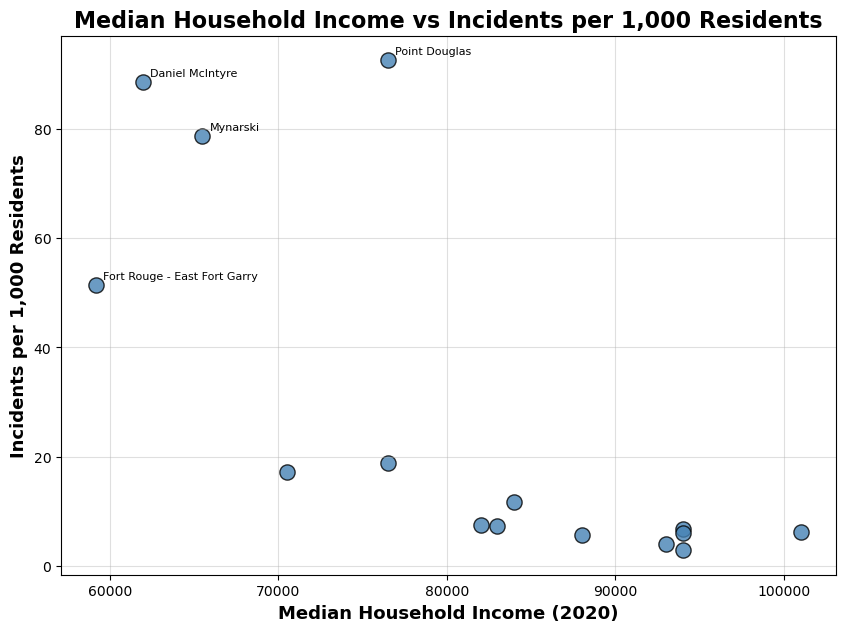

In [12]:
# plotting
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(by_ward["median_household_income"], by_ward["incidents_per_1000"],
           color="steelblue", edgecolor="black", s=120, alpha=0.8)

# annotating main wards    
main_wards = ["Point Douglas", "Mynarski", "Daniel McIntyre", "Fort Rouge - East Fort Garry"]
main_wards_df = by_ward[by_ward["ward"].isin(main_wards)]
for _, row in main_wards_df.iterrows():
    ax.annotate(row["ward"], (row["median_household_income"], row["incidents_per_1000"]),
                fontsize=8, xytext=(5, 4), textcoords="offset points")

# labeling the plot
ax.set_title("Median Household Income vs Incidents per 1,000 Residents", fontsize=16, fontweight="bold")
ax.set_xlabel("Median Household Income (2020)", fontsize=13, fontweight="bold")
ax.set_ylabel("Incidents per 1,000 Residents", fontsize=13, fontweight="bold")

# displaying the chart
ax.grid(alpha=0.4)
plt.show()

The relationship between income and overdose rate is clearly negative. The four labeled wards, Point Douglas, Mynarski, Daniel McIntyre, and Fort Rouge, are the ones with the lowest median household incomes and the highest incidents per 1,000 residents. The pattern is not linear: below roughly $80,000 in median income, overdose rates are dramatically higher, while above that level the numbers stay consistently low. This suggests that income plays a much bigger role in overdose risk than population size, and that where someone lives in Winnipeg is closely tied to how wealthy their ward is.

## Q4. Is age or gender related to needing multiple doses?
This visualization will look for patterns in demographics charachteristics like age and gender to see if they relate to the necessity of multiple doses.

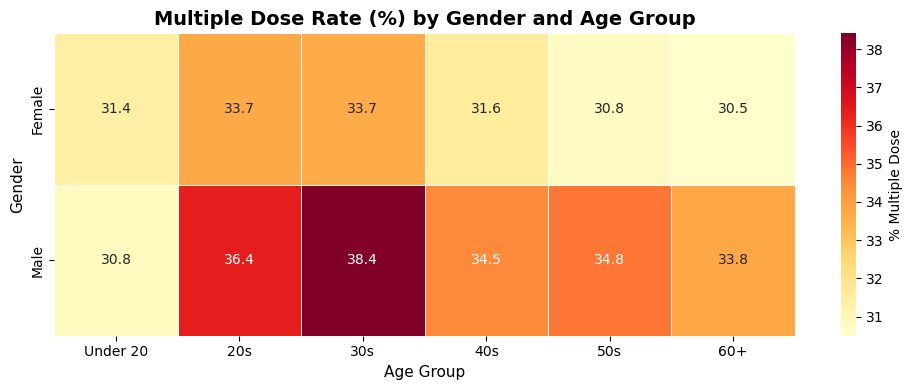

In [13]:
# preparing the data

# separating age range in bigger sections (age_group)
bins = [0, 19, 29, 39, 49, 59, 200]
labels = ["Under 20", "20s", "30s", "40s", "50s", "60+"]
df["age_group"] = pd.cut(df["age_midpoint"], bins=bins, labels=labels)

pivot = df.groupby(["gender", "age_group"], observed="True")["is_multiple_dose"].mean() * 100
pivot = pivot.unstack()

# plotting
fig, ax = plt.subplots(figsize=(10, 4))

# creating a heatmap for % of multiple dose by gender (y-axis) and age_group (x_axis)
# showing the percentages for each point (square)
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "% Multiple Dose"}, ax=ax)

# labeling the plot
ax.set_title("Multiple Dose Rate (%) by Gender and Age Group", fontsize=14, fontweight="bold")
ax.set_xlabel("Age Group", fontsize=11)
ax.set_ylabel("Gender", fontsize=11)

# displaying the chart
plt.tight_layout()
plt.show()

The visual clearly shows a darker Male section, meaning that males have more severe incidents. Males in their 20s and 30s are the most likely to need multiple doses, with 36.4% and 38.4% respectively. Females show a much more stable pattern across all age groups, but still peaking at the 20s and 30s. For paramedics teams, this means that calls involving young/adult male patients may be more likely to require extra doses on hand.